# MODELOS MACHINE LEARNING PARA CLASIFICACION

In [1]:
# ======================================================
# IMPORTACIÓN DE LIBRERÍAS
# ======================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                           confusion_matrix, classification_report, roc_curve, auc,
                           roc_auc_score, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

In [2]:
# ======================================================
# 1. CARGA Y EXPLORACIÓN DE DATOS
# ======================================================

print("=" * 70)
print("1. CARGA Y EXPLORACIÓN DE DATOS - COMPRAR O ALQUILAR")
print("=" * 70)

# URL del dataset
url = "https://raw.githubusercontent.com/Darwin2016/dataset2022/main/dataSETS/comprar_alquilar2024.csv"

# Cargar datos
try:
    df = pd.read_csv(url, encoding='utf-8')
    print("✓ Dataset cargado correctamente")
except:
    # Si falla con utf-8, probar latin-1
    df = pd.read_csv(url, encoding='latin-1')
    print("✓ Dataset cargado con encoding latin-1")

print(f"\nDimensiones del dataset: {df.shape}")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

# Mostrar información del dataset
print("\nInformación del dataset:")
print(df.info())

print("\nPrimeras 5 filas:")
print(df.head())

print("\nEstadísticas descriptivas:")
print(df.describe())

print("\nValores nulos por columna:")
print(df.isnull().sum())


1. CARGA Y EXPLORACIÓN DE DATOS - COMPRAR O ALQUILAR
✓ Dataset cargado correctamente

Dimensiones del dataset: (202, 10)
Filas: 202, Columnas: 10

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB
None

Primeras 5 filas:
   ingresos  gastos_comunes  pago_coche  gastos_otros  ahorros  vivienda  \
0      6000            1000           0           600    50000    4


2. ANÁLISIS EXPLORATORIO DE DATOS

Distribución de la variable objetivo 'comprar':
comprar
0    135
1     67
Name: count, dtype: int64


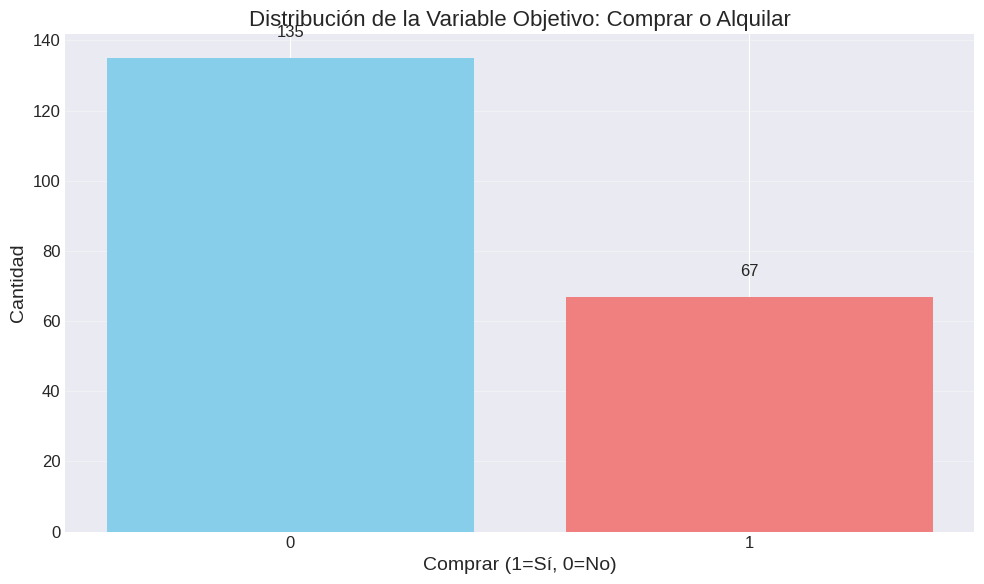


Variables numéricas: ['ingresos', 'gastos_comunes', 'pago_coche', 'gastos_otros', 'ahorros', 'vivienda', 'estado_civil', 'hijos', 'trabajo', 'comprar']


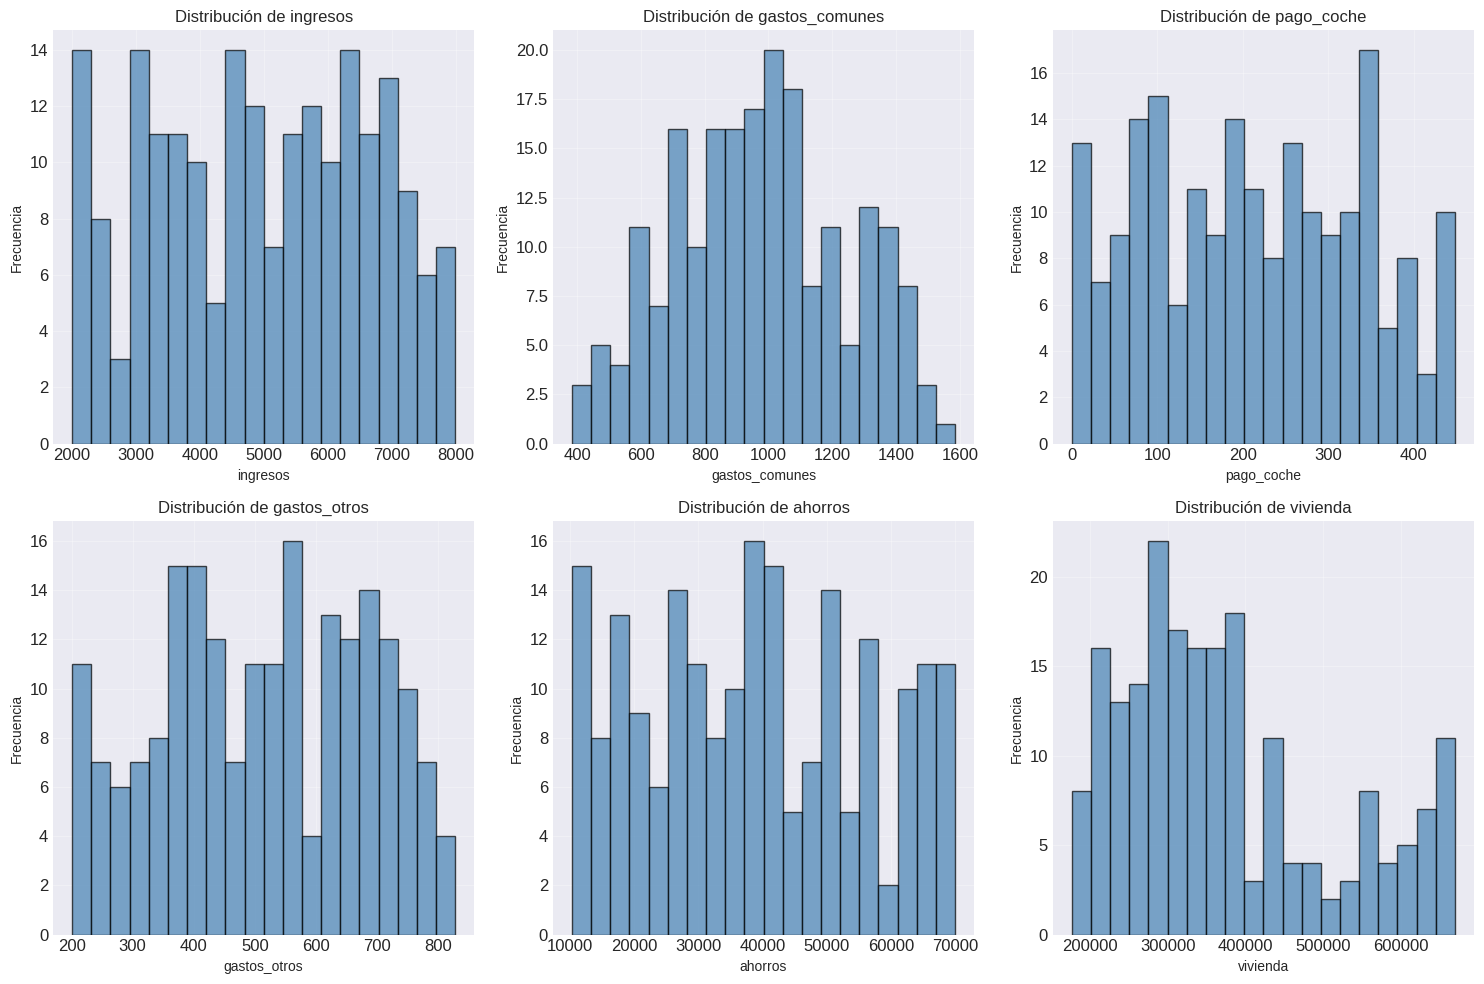

In [3]:
# ======================================================
# 2. ANÁLISIS EXPLORATORIO DE DATOS (EDA)
# ======================================================

print("\n" + "=" * 70)
print("2. ANÁLISIS EXPLORATORIO DE DATOS")
print("=" * 70)

# Distribución de la variable objetivo
print("\nDistribución de la variable objetivo 'comprar':")
target_dist = df['comprar'].value_counts()
print(target_dist)

plt.figure(figsize=(10, 6))
bars = plt.bar(target_dist.index.astype(str), target_dist.values, color=['skyblue', 'lightcoral'])
plt.title('Distribución de la Variable Objetivo: Comprar o Alquilar', fontsize=16)
plt.xlabel('Comprar (1=Sí, 0=No)', fontsize=14)
plt.ylabel('Cantidad', fontsize=14)
plt.grid(axis='y', alpha=0.3)

# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plt.show()

# Análisis de variables numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nVariables numéricas: {numeric_cols}")

if 'comprar' in numeric_cols:
    numeric_cols.remove('comprar')

# Visualización de distribuciones
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    if idx < len(axes):
        axes[idx].hist(df[col], bins=20, alpha=0.7, color='steelblue', edgecolor='black')
        axes[idx].set_title(f'Distribución de {col}', fontsize=12)
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Frecuencia', fontsize=10)
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [4]:
# ======================================================
# 3. PREPROCESAMIENTO DE DATOS
# ======================================================

print("\n" + "=" * 70)
print("3. PREPROCESAMIENTO DE DATOS")
print("=" * 70)

# Separar características y variable objetivo
X = df.drop('comprar', axis=1)
y = df['comprar']

print(f"Características (X): {X.shape}")
print(f"Variable objetivo (y): {y.shape}")

# Identificar columnas categóricas
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
print(f"\nColumnas categóricas: {categorical_cols}")

# Codificar variables categóricas si existen
if categorical_cols:
    print("Codificando variables categóricas...")
    le = LabelEncoder()
    for col in categorical_cols:
        X[col] = le.fit_transform(X[col])
    print("✓ Variables categóricas codificadas")

# Verificar balance de clases
class_balance = y.value_counts(normalize=True) * 100
print(f"\nBalance de clases:")
for cls, perc in class_balance.items():
    print(f"  Clase {cls}: {perc:.2f}%")

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nDivisión train-test:")
print(f"  Entrenamiento: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Prueba: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

# Escalar características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Datos escalados con StandardScaler")


3. PREPROCESAMIENTO DE DATOS
Características (X): (202, 9)
Variable objetivo (y): (202,)

Columnas categóricas: []

Balance de clases:
  Clase 0: 66.83%
  Clase 1: 33.17%

División train-test:
  Entrenamiento: 161 muestras (79.7%)
  Prueba: 41 muestras (20.3%)

✓ Datos escalados con StandardScaler


In [5]:
# ======================================================
# 4. DEFINICIÓN Y ENTRENAMIENTO DE MODELOS
# ======================================================

print("\n" + "=" * 70)
print("4. ENTRENAMIENTO DE MÚLTIPLES MODELOS")
print("=" * 70)

# Definir modelos a entrenar
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(probability=True, random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Diccionario para almacenar resultados
results = {
    'Model': [],
    'Accuracy': [],
    'Precision': [],
    'Recall': [],
    'F1-Score': [],
    'ROC-AUC': []
}

# Entrenar y evaluar cada modelo
for name, model in models.items():
    print(f"\nEntrenando {name}...")

    # Entrenar modelo
    model.fit(X_train_scaled, y_train)

    # Predecir
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, "predict_proba") else None

    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else 0

    # Guardar resultados
    results['Model'].append(name)
    results['Accuracy'].append(accuracy)
    results['Precision'].append(precision)
    results['Recall'].append(recall)
    results['F1-Score'].append(f1)
    results['ROC-AUC'].append(roc_auc)

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    if roc_auc > 0:
        print(f"  ROC-AUC: {roc_auc:.4f}")

# Crear DataFrame con resultados
results_df = pd.DataFrame(results)
print("\n" + "=" * 70)
print("RESULTADOS COMPARATIVOS DE TODOS LOS MODELOS")
print("=" * 70)
print(results_df.round(4))



4. ENTRENAMIENTO DE MÚLTIPLES MODELOS

Entrenando Logistic Regression...
  Accuracy: 0.8780
  Precision: 1.0000
  Recall: 0.6429
  F1-Score: 0.7826
  ROC-AUC: 0.9947

Entrenando Naive Bayes...
  Accuracy: 0.8049
  Precision: 0.8000
  Recall: 0.5714
  F1-Score: 0.6667
  ROC-AUC: 0.9074

Entrenando Decision Tree...
  Accuracy: 0.9268
  Precision: 1.0000
  Recall: 0.7857
  F1-Score: 0.8800
  ROC-AUC: 0.8810

Entrenando Random Forest...
  Accuracy: 0.8537
  Precision: 0.9000
  Recall: 0.6429
  F1-Score: 0.7500
  ROC-AUC: 0.9497

Entrenando K-Nearest Neighbors...
  Accuracy: 0.8780
  Precision: 0.9091
  Recall: 0.7143
  F1-Score: 0.8000
  ROC-AUC: 0.8902

Entrenando Support Vector Machine...
  Accuracy: 0.8293
  Precision: 0.8889
  Recall: 0.5714
  F1-Score: 0.6957
  ROC-AUC: 0.9735

Entrenando AdaBoost...
  Accuracy: 0.8780
  Precision: 0.9091
  Recall: 0.7143
  F1-Score: 0.8000
  ROC-AUC: 0.9762

Entrenando Gradient Boosting...
  Accuracy: 0.9024
  Precision: 1.0000
  Recall: 0.7143
  F1


5. MATRICES DE CONFUSIÓN - VISUALIZACIÓN GRÁFICA


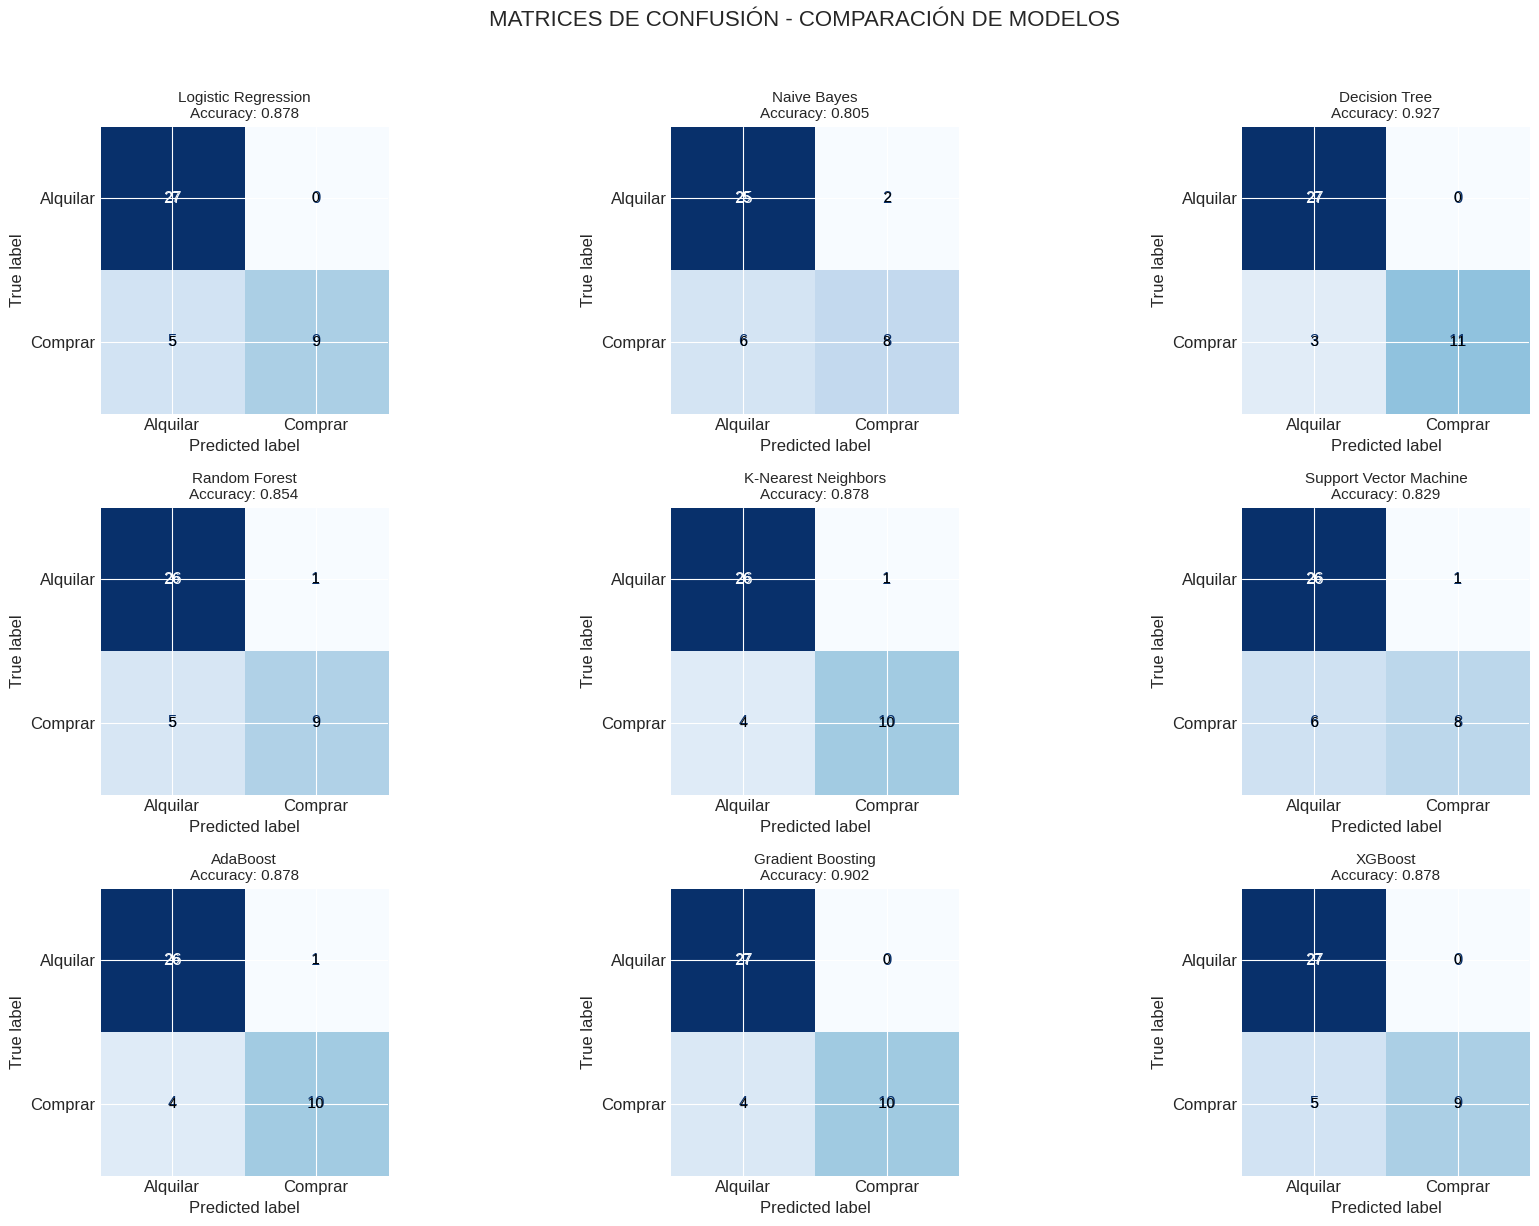

In [6]:
# ======================================================
# 5. MATRICES DE CONFUSIÓN PARA CADA MODELO
# ======================================================

print("\n" + "=" * 70)
print("5. MATRICES DE CONFUSIÓN - VISUALIZACIÓN GRÁFICA")
print("=" * 70)

# Configurar subplots para matrices de confusión
n_models = len(models)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4*n_rows))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    # Obtener predicciones
    y_pred = model.predict(X_test_scaled)

    # Calcular matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear visualización
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Alquilar', 'Comprar'])
    disp.plot(ax=axes[idx], cmap='Blues', colorbar=False)
    axes[idx].set_title(f'{name}\nAccuracy: {results_df.loc[idx, "Accuracy"]:.3f}', fontsize=11)

    # Añadir valores de texto
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            axes[idx].text(j, i, f'{cm[i, j]}',
                          ha='center', va='center',
                          color='white' if cm[i, j] > cm.max()/2 else 'black',
                          fontsize=10)

# Ocultar ejes vacíos si los hay
for idx in range(len(models), len(axes)):
    axes[idx].axis('off')

plt.suptitle('MATRICES DE CONFUSIÓN - COMPARACIÓN DE MODELOS', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


6. CURVAS ROC Y ÁREA BAJO LA CURVA (AUC)


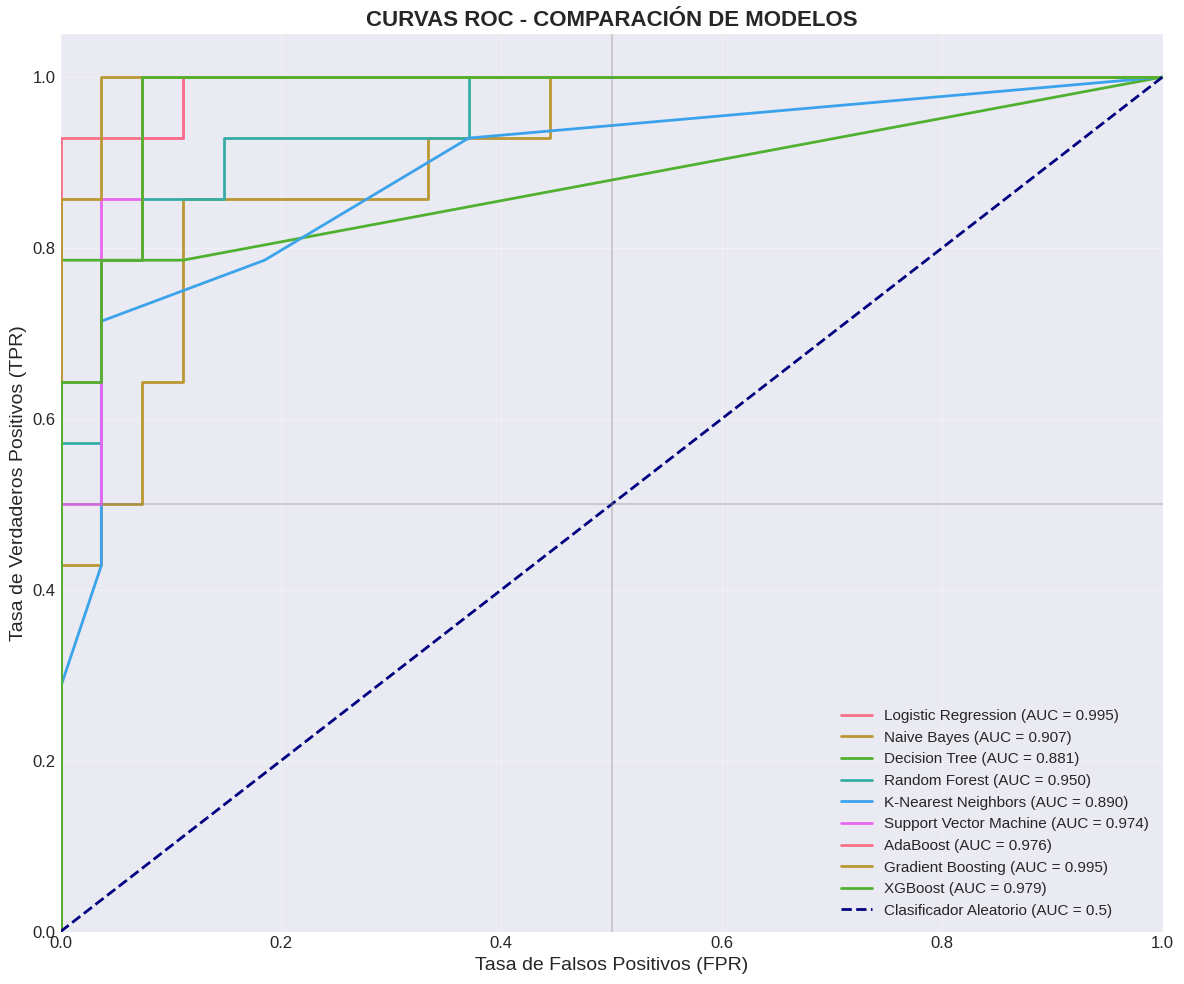

In [7]:
# ======================================================
# 6. CURVAS ROC Y ÁREA BAJO LA CURVA (AUC)
# ======================================================

print("\n" + "=" * 70)
print("6. CURVAS ROC Y ÁREA BAJO LA CURVA (AUC)")
print("=" * 70)

# Configurar gráfico de curvas ROC
plt.figure(figsize=(12, 10))

# Curva ROC para cada modelo
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        # Obtener probabilidades
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        # Calcular curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Graficar curva ROC
        plt.plot(fpr, tpr, lw=2,
                label=f'{name} (AUC = {roc_auc:.3f})')

# Línea de referencia (clasificador aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5)')

# Configurar gráfico
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=14)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=14)
plt.title('CURVAS ROC - COMPARACIÓN DE MODELOS', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

# Añadir cuadrícula de referencia
plt.axhline(y=0.5, color='gray', linestyle='-', alpha=0.3)
plt.axvline(x=0.5, color='gray', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()


7. COMPARACIÓN DETALLADA DE RENDIMIENTO

Ranking de modelos por ROC-AUC:
                    Model  ROC-AUC  Accuracy  F1-Score
0       Gradient Boosting   0.9947    0.9024    0.8333
1     Logistic Regression   0.9947    0.8780    0.7826
2                 XGBoost   0.9788    0.8780    0.7826
3                AdaBoost   0.9762    0.8780    0.8000
4  Support Vector Machine   0.9735    0.8293    0.6957
5           Random Forest   0.9497    0.8537    0.7500
6             Naive Bayes   0.9074    0.8049    0.6667
7     K-Nearest Neighbors   0.8902    0.8780    0.8000
8           Decision Tree   0.8810    0.9268    0.8800


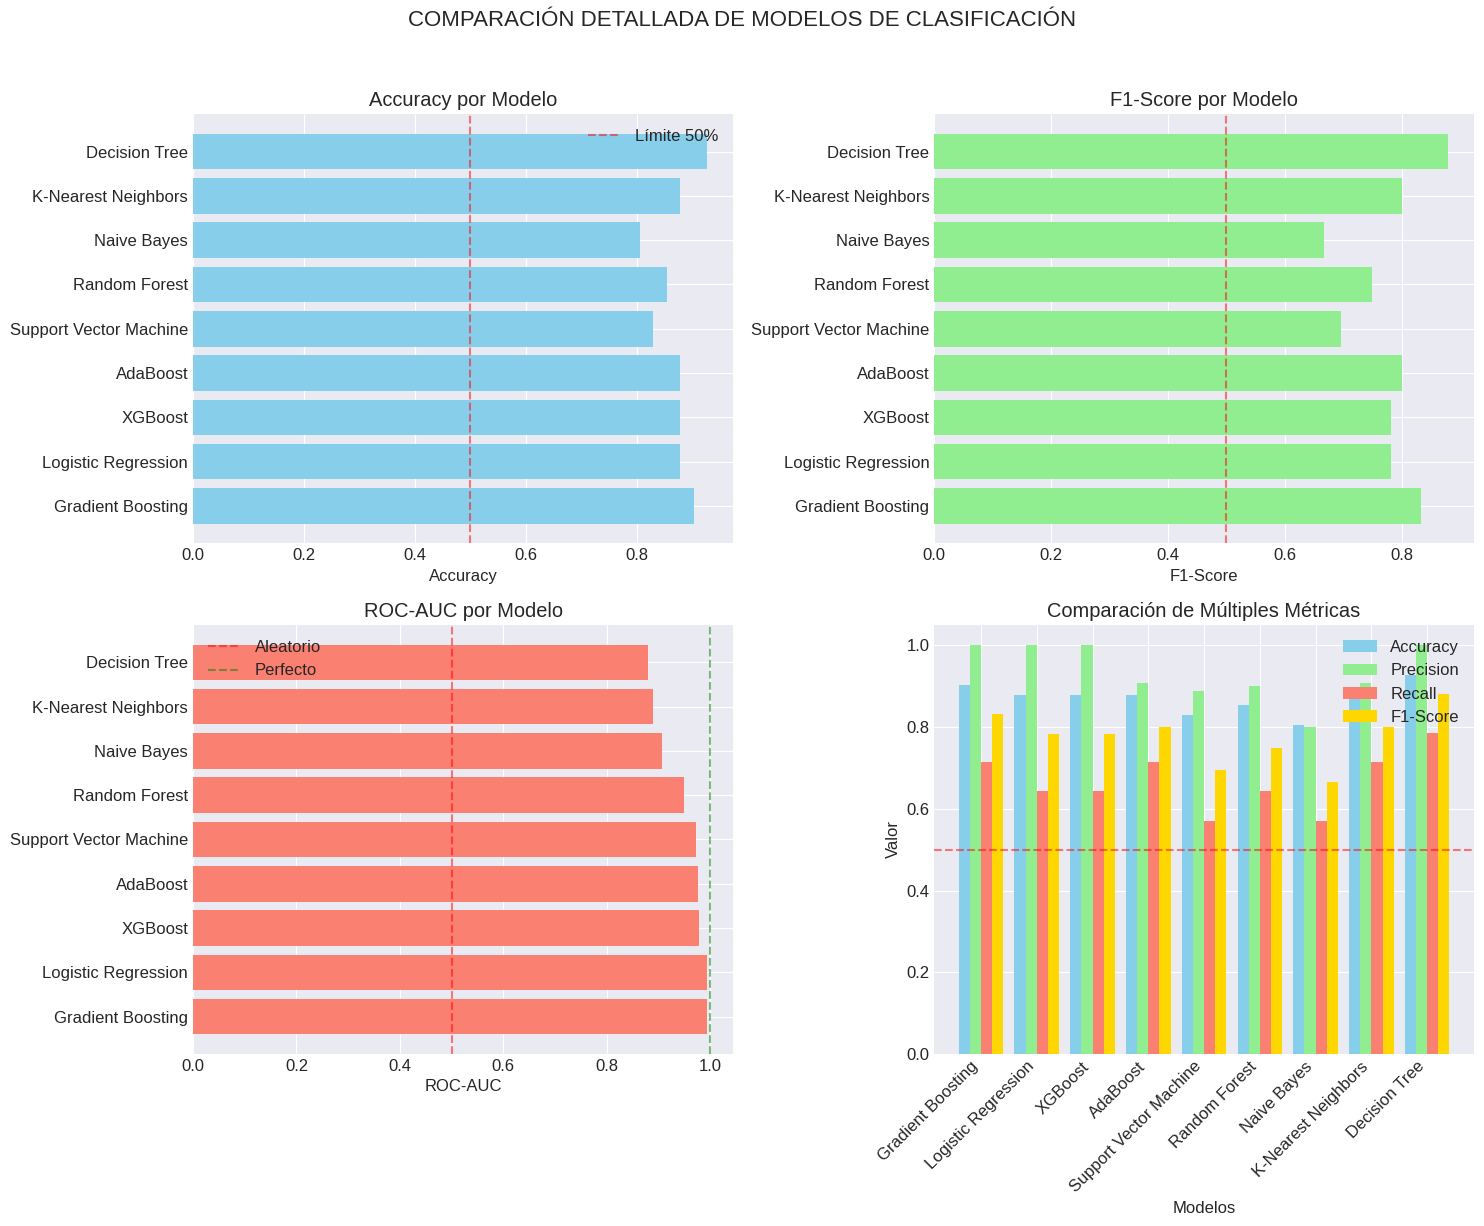

In [8]:
# ======================================================
# 7. COMPARACIÓN DETALLADA DE MÉTRICAS
# ======================================================

print("\n" + "=" * 70)
print("7. COMPARACIÓN DETALLADA DE RENDIMIENTO")
print("=" * 70)

# Ordenar resultados por ROC-AUC
results_sorted = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)

print("\nRanking de modelos por ROC-AUC:")
print(results_sorted[['Model', 'ROC-AUC', 'Accuracy', 'F1-Score']].round(4))

# Visualización de comparación de métricas
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Gráfico 1: Accuracy por modelo
axes[0, 0].barh(results_sorted['Model'], results_sorted['Accuracy'], color='skyblue')
axes[0, 0].set_xlabel('Accuracy')
axes[0, 0].set_title('Accuracy por Modelo')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Límite 50%')
axes[0, 0].legend()

# Gráfico 2: F1-Score por modelo
axes[0, 1].barh(results_sorted['Model'], results_sorted['F1-Score'], color='lightgreen')
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('F1-Score por Modelo')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

# Gráfico 3: ROC-AUC por modelo
axes[1, 0].barh(results_sorted['Model'], results_sorted['ROC-AUC'], color='salmon')
axes[1, 0].set_xlabel('ROC-AUC')
axes[1, 0].set_title('ROC-AUC por Modelo')
axes[1, 0].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Aleatorio')
axes[1, 0].axvline(x=1.0, color='green', linestyle='--', alpha=0.5, label='Perfecto')
axes[1, 0].legend()

# Gráfico 4: Comparación múltiple
metrics_plot = results_sorted[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
x = range(len(results_sorted))
width = 0.2
axes[1, 1].bar(np.array(x) - 1.5*width, metrics_plot['Accuracy'], width, label='Accuracy', color='skyblue')
axes[1, 1].bar(np.array(x) - 0.5*width, metrics_plot['Precision'], width, label='Precision', color='lightgreen')
axes[1, 1].bar(np.array(x) + 0.5*width, metrics_plot['Recall'], width, label='Recall', color='salmon')
axes[1, 1].bar(np.array(x) + 1.5*width, metrics_plot['F1-Score'], width, label='F1-Score', color='gold')
axes[1, 1].set_xlabel('Modelos')
axes[1, 1].set_ylabel('Valor')
axes[1, 1].set_title('Comparación de Múltiples Métricas')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(results_sorted['Model'], rotation=45, ha='right')
axes[1, 1].legend()
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)

plt.suptitle('COMPARACIÓN DETALLADA DE MODELOS DE CLASIFICACIÓN', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [9]:
# ======================================================
# 8. SELECCIÓN DEL MEJOR MODELO Y OPTIMIZACIÓN
# ======================================================

print("\n" + "=" * 70)
print("8. SELECCIÓN Y OPTIMIZACIÓN DEL MEJOR MODELO")
print("=" * 70)

# Identificar el mejor modelo según ROC-AUC
best_model_name = results_sorted.loc[0, 'Model']
best_model = models[best_model_name]

print(f"\nMejor modelo identificado: {best_model_name}")
print(f"ROC-AUC: {results_sorted.loc[0, 'ROC-AUC']:.4f}")
print(f"Accuracy: {results_sorted.loc[0, 'Accuracy']:.4f}")
print(f"F1-Score: {results_sorted.loc[0, 'F1-Score']:.4f}")

# Reporte de clasificación detallado del mejor modelo
print(f"\nReporte de clasificación detallado - {best_model_name}:")
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['Alquilar', 'Comprar']))



8. SELECCIÓN Y OPTIMIZACIÓN DEL MEJOR MODELO

Mejor modelo identificado: Gradient Boosting
ROC-AUC: 0.9947
Accuracy: 0.9024
F1-Score: 0.8333

Reporte de clasificación detallado - Gradient Boosting:
              precision    recall  f1-score   support

    Alquilar       0.87      1.00      0.93        27
     Comprar       1.00      0.71      0.83        14

    accuracy                           0.90        41
   macro avg       0.94      0.86      0.88        41
weighted avg       0.92      0.90      0.90        41




9. IMPORTANCIA DE CARACTERÍSTICAS

Importancia de características - Gradient Boosting:
   Característica  Importancia
0        ingresos     0.365217
5        vivienda     0.363181
8         trabajo     0.130605
2      pago_coche     0.044638
4         ahorros     0.032804
3    gastos_otros     0.025205
7           hijos     0.021910
1  gastos_comunes     0.015685
6    estado_civil     0.000754


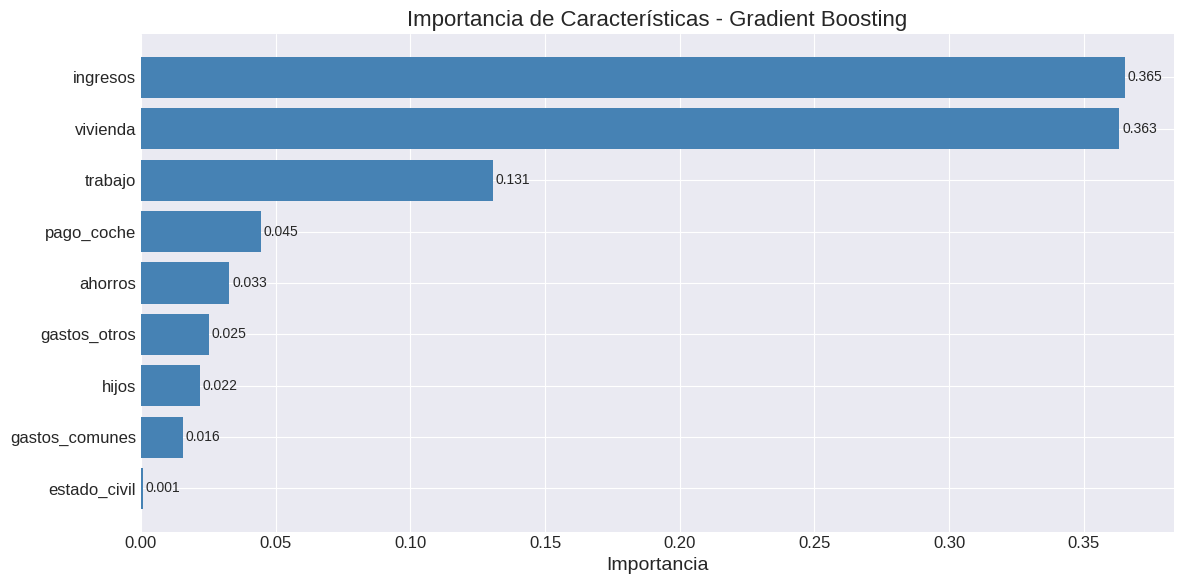

In [10]:
# ======================================================
# 9. IMPORTANCIA DE CARACTERÍSTICAS (PARA MODELOS CON ESTA CAPACIDAD)
# ======================================================

print("\n" + "=" * 70)
print("9. IMPORTANCIA DE CARACTERÍSTICAS")
print("=" * 70)

# Verificar si el mejor modelo tiene importancia de características
if hasattr(best_model, 'feature_importances_'):
    print(f"\nImportancia de características - {best_model_name}:")
    feature_importance = pd.DataFrame({
        'Característica': X.columns,
        'Importancia': best_model.feature_importances_
    }).sort_values('Importancia', ascending=False)

    print(feature_importance)

    # Visualizar importancia de características
    plt.figure(figsize=(12, 6))
    bars = plt.barh(feature_importance['Característica'],
                   feature_importance['Importancia'],
                   color='steelblue')
    plt.xlabel('Importancia', fontsize=14)
    plt.title(f'Importancia de Características - {best_model_name}', fontsize=16)
    plt.gca().invert_yaxis()  # Mayor importancia arriba

    # Añadir valores en las barras
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.001, bar.get_y() + bar.get_height()/2,
                f'{width:.3f}', ha='left', va='center', fontsize=10)

    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    # Para modelos lineales como Logistic Regression
    print(f"\nCoeficientes - {best_model_name}:")
    coefficients = pd.DataFrame({
        'Característica': X.columns,
        'Coeficiente': best_model.coef_[0]
    }).sort_values('Coeficiente', ascending=False)

    print(coefficients)

In [11]:
# ======================================================
# 10. SISTEMA DE PREDICCIÓN CON NUEVOS DATOS
# ======================================================

print("\n" + "=" * 70)
print("10. SISTEMA DE PREDICCIÓN CON NUEVOS DATOS")
print("=" * 70)

def predecir_comprar_alquilar(model, scaler, input_data, feature_names=None):
    """
    Predice si comprar o alquilar basado en datos de entrada

    Parámetros:
    model: modelo entrenado
    scaler: scaler entrenado
    input_data: lista o array con valores de características
    feature_names: nombres de las características (opcional)

    Retorna:
    probabilidad de comprar (0-1) y recomendación
    """
    # Convertir a array numpy
    input_array = np.array(input_data).reshape(1, -1)

    # Escalar datos
    input_scaled = scaler.transform(input_array)

    # Predecir probabilidad
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(input_scaled)[0, 1]  # Probabilidad de clase 1 (comprar)
    else:
        proba = model.predict(input_scaled)[0]

    # Determinar recomendación
    if proba >= 0.5:
        decision = "COMPRAR"
        confidence = proba
    else:
        decision = "ALQUILAR"
        confidence = 1 - proba

    # Formatear resultados
    result = {
        'probabilidad_comprar': proba,
        'decision': decision,
        'confianza': confidence,
        'probabilidad_alquilar': 1 - proba
    }

    return result

# Función para interfaz de usuario simple
def interfaz_prediccion():
    """
    Interfaz simple para ingresar datos y obtener predicción
    """
    print("\n" + "=" * 50)
    print("INTERFAZ DE PREDICCIÓN - COMPRAR O ALQUILAR")
    print("=" * 50)

    print(f"\nCaracterísticas disponibles: {list(X.columns)}")
    print("Ingrese los valores para cada característica:")

    input_values = []
    for feature in X.columns:
        try:
            value = float(input(f"{feature}: "))
            input_values.append(value)
        except:
            print(f"Error en {feature}. Usando valor por defecto 0.")
            input_values.append(0)

    # Hacer predicción
    resultado = predecir_comprar_alquilar(best_model, scaler, input_values, X.columns)

    print("\n" + "=" * 50)
    print("RESULTADO DE LA PREDICCIÓN")
    print("=" * 50)
    print(f"\nProbabilidad de COMPRAR: {resultado['probabilidad_comprar']:.2%}")
    print(f"Probabilidad de ALQUILAR: {resultado['probabilidad_alquilar']:.2%}")
    print(f"\nDECISIÓN RECOMENDADA: {resultado['decision']}")
    print(f"Confianza: {resultado['confianza']:.2%}")

    # Interpretación
    if resultado['probabilidad_comprar'] >= 0.7:
        print("\nInterpretación: Alta probabilidad de que sea mejor COMPRAR")
    elif resultado['probabilidad_comprar'] >= 0.5:
        print("\nInterpretación: Moderada probabilidad de que sea mejor COMPRAR")
    elif resultado['probabilidad_comprar'] >= 0.3:
        print("\nInterpretación: Moderada probabilidad de que sea mejor ALQUILAR")
    else:
        print("\nInterpretación: Alta probabilidad de que sea mejor ALQUILAR")

    return resultado

# Ejemplos de predicción con casos de prueba
print("\nEjemplos de predicción con datos reales del conjunto de prueba:")

# Tomar algunos ejemplos del conjunto de prueba
ejemplos_idx = [0, 10, 20, 50]  # Índices de ejemplos

for idx in ejemplos_idx:
    if idx < len(X_test):
        datos_ejemplo = X_test.iloc[idx].values
        valor_real = y_test.iloc[idx]

        resultado = predecir_comprar_alquilar(best_model, scaler, datos_ejemplo, X.columns)

        print(f"\nEjemplo {idx + 1}:")
        print(f"Datos: {dict(zip(X.columns, datos_ejemplo.round(2)))}")
        print(f"Valor real: {'Comprar' if valor_real == 1 else 'Alquilar'}")
        print(f"Predicción: {resultado['decision']} (prob: {resultado['probabilidad_comprar']:.2%})")
        print(f"Correcto: {'✓' if (resultado['decision'] == 'COMPRAR') == (valor_real == 1) else '✗'}")



10. SISTEMA DE PREDICCIÓN CON NUEVOS DATOS

Ejemplos de predicción con datos reales del conjunto de prueba:

Ejemplo 1:
Datos: {'ingresos': np.int64(3043), 'gastos_comunes': np.int64(578), 'pago_coche': np.int64(290), 'gastos_otros': np.int64(460), 'ahorros': np.int64(28647), 'vivienda': np.int64(229343), 'estado_civil': np.int64(2), 'hijos': np.int64(1), 'trabajo': np.int64(5)}
Valor real: Alquilar
Predicción: ALQUILAR (prob: 0.44%)
Correcto: ✓

Ejemplo 11:
Datos: {'ingresos': np.int64(7289), 'gastos_comunes': np.int64(1458), 'pago_coche': np.int64(209), 'gastos_otros': np.int64(243), 'ahorros': np.int64(41233), 'vivienda': np.int64(488643), 'estado_civil': np.int64(2), 'hijos': np.int64(1), 'trabajo': np.int64(5)}
Valor real: Comprar
Predicción: COMPRAR (prob: 85.38%)
Correcto: ✓

Ejemplo 21:
Datos: {'ingresos': np.int64(4426), 'gastos_comunes': np.int64(1328), 'pago_coche': np.int64(152), 'gastos_otros': np.int64(480), 'ahorros': np.int64(11593), 'vivienda': np.int64(245454), 'esta

In [12]:
# ======================================================
# 11. VALIDACIÓN CRUZADA PARA EL MEJOR MODELO
# ======================================================

print("\n" + "=" * 70)
print("11. VALIDACIÓN CRUZADA - MEJOR MODELO")
print("=" * 70)

from sklearn.model_selection import cross_val_score, StratifiedKFold

# Configurar validación cruzada estratificada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluar el mejor modelo con validación cruzada
cv_scores = cross_val_score(best_model, X_train_scaled, y_train,
                           cv=cv, scoring='roc_auc')

print(f"\nValidación Cruzada (5 folds) - {best_model_name}:")
print(f"  Scores ROC-AUC: {cv_scores.round(4)}")
print(f"  Media ROC-AUC: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

# Predicciones con validación cruzada
y_pred_cv = cross_val_predict(best_model, X_train_scaled, y_train, cv=cv, method='predict_proba')[:, 1]
fpr_cv, tpr_cv, _ = roc_curve(y_train, y_pred_cv)
roc_auc_cv = auc(fpr_cv, tpr_cv)

print(f"  ROC-AUC con CV: {roc_auc_cv:.4f}")


11. VALIDACIÓN CRUZADA - MEJOR MODELO

Validación Cruzada (5 folds) - Gradient Boosting:
  Scores ROC-AUC: [0.9008 0.8918 0.974  0.9545 0.9273]
  Media ROC-AUC: 0.9297 (±0.0312)
  ROC-AUC con CV: 0.9278


In [13]:
# ======================================================
# 12. GUARDAR MODELO ENTRENADO
# ======================================================

print("\n" + "=" * 70)
print("12. GUARDAR MODELOS ENTRENADOS")
print("=" * 70)

import joblib
import os

# Crear directorio para modelos si no existe
if not os.path.exists('modelos_guardados'):
    os.makedirs('modelos_guardados')

# Guardar el mejor modelo
joblib.dump(best_model, 'modelos_guardados/mejor_modelo_comprar_alquilar.pkl')
joblib.dump(scaler, 'modelos_guardados/scaler_comprar_alquilar.pkl')
joblib.dump(X.columns, 'modelos_guardados/feature_names.pkl')

print("✓ Mejor modelo guardado como: 'modelos_guardados/mejor_modelo_comprar_alquilar.pkl'")
print("✓ Scaler guardado como: 'modelos_guardados/scaler_comprar_alquilar.pkl'")
print("✓ Nombres de características guardados")

# Función para cargar y usar el modelo guardado
def cargar_modelo_y_predecir(datos_nuevos):
    """
    Carga el modelo guardado y hace una predicción
    """
    modelo_cargado = joblib.load('modelos_guardados/mejor_modelo_comprar_alquilar.pkl')
    scaler_cargado = joblib.load('modelos_guardados/scaler_comprar_alquilar.pkl')
    feature_names_cargado = joblib.load('modelos_guardados/feature_names.pkl')

    return predecir_comprar_alquilar(modelo_cargado, scaler_cargado, datos_nuevos, feature_names_cargado)

print("\n✓ Sistema de predicción listo para producción")



12. GUARDAR MODELOS ENTRENADOS
✓ Mejor modelo guardado como: 'modelos_guardados/mejor_modelo_comprar_alquilar.pkl'
✓ Scaler guardado como: 'modelos_guardados/scaler_comprar_alquilar.pkl'
✓ Nombres de características guardados

✓ Sistema de predicción listo para producción


In [14]:
# ======================================================
# 13. RESUMEN FINAL Y CONCLUSIONES
# ======================================================

print("\n" + "=" * 70)
print("13. RESUMEN FINAL Y CONCLUSIONES")
print("=" * 70)

print(f"\nDataset analizado: Comprar o Alquilar")
print(f"Tamaño del dataset: {df.shape[0]} muestras, {df.shape[1]} características")
print(f"Variable objetivo: 'comprar' (1=Comprar, 0=Alquilar)")
print(f"Distribución de clases: {class_balance[0]:.1f}% Alquilar, {class_balance[1]:.1f}% Comprar")

print(f"\nModelos evaluados: {len(models)}")
print(f"Mejor modelo: {best_model_name}")
print(f"  ROC-AUC en prueba: {results_sorted.loc[0, 'ROC-AUC']:.4f}")
print(f"  Accuracy en prueba: {results_sorted.loc[0, 'Accuracy']:.4f}")

print(f"\nCaracterísticas más importantes identificadas:")
if 'feature_importance' in locals():
    top_features = feature_importance.head(3)
    for _, row in top_features.iterrows():
        print(f"  {row['Característica']}: {row['Importancia']:.3f}")

print("\n" + "=" * 70)
print("ANÁLISIS COMPLETO FINALIZADO")
print("=" * 70)
print("\nPara usar el sistema de predicción:")
print("1. Use la función 'interfaz_prediccion()' para ingresar datos manualmente")
print("2. Use 'cargar_modelo_y_predecir(datos_nuevos)' para predicciones programáticas")
print("3. Los modelos están guardados en la carpeta 'modelos_guardados/'")


13. RESUMEN FINAL Y CONCLUSIONES

Dataset analizado: Comprar o Alquilar
Tamaño del dataset: 202 muestras, 10 características
Variable objetivo: 'comprar' (1=Comprar, 0=Alquilar)
Distribución de clases: 66.8% Alquilar, 33.2% Comprar

Modelos evaluados: 9
Mejor modelo: Gradient Boosting
  ROC-AUC en prueba: 0.9947
  Accuracy en prueba: 0.9024

Características más importantes identificadas:
  ingresos: 0.365
  vivienda: 0.363
  trabajo: 0.131

ANÁLISIS COMPLETO FINALIZADO

Para usar el sistema de predicción:
1. Use la función 'interfaz_prediccion()' para ingresar datos manualmente
2. Use 'cargar_modelo_y_predecir(datos_nuevos)' para predicciones programáticas
3. Los modelos están guardados en la carpeta 'modelos_guardados/'
